# 🧠 Demo II — Neural Networks in Action
### NN Model Demonstrations · Deep Learning Basics Session

---

In this demo you will run **five pretrained models** — one for each architecture covered in Part 2.
All models are loaded from public libraries; no training is required.

| # | Architecture | Task | Library |
|---|---|---|---|
| 1 | **ANN** | Tabular classification (Iris) | TensorFlow / Keras |
| 2 | **CNN** | Image classification | Keras Applications (MobileNetV2) |
| 3 | **RNN** | Sentiment analysis (LSTM) | TensorFlow / Keras |

**Libraries used:** `tensorflow`, `keras`, `datasets` (Hugging Face)

---

## ⚙️ Setup — Install & Import Libraries

In [1]:
# Install required libraries
!pip install pillow requests matplotlib numpy scikit-learn --quiet


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Data helpers ─────────────────────────────────────────────────────────────
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f'✅  TensorFlow  : {tf.__version__}')
print(f'✅  Keras       : {keras.__version__}')

print('\nAll libraries loaded successfully!')



✅  TensorFlow  : 2.21.0
✅  Keras       : 3.15.1

All libraries loaded successfully!


---
## 1 · ANN — Tabular Classification with Keras

**Architecture:** Artificial Neural Network (fully-connected layers)  
**Task:** Classify Iris flowers into 3 species using 4 numeric features  
**Dataset:** Iris (built-in to scikit-learn, 150 samples)

> 💡 ANNs shine on **structured / tabular data** where features are already numbers.

In [3]:
# ── Load the Iris dataset ────────────────────────────────────────────────────
iris = load_iris()
X, y = iris.data, iris.target          # 4 features, 3 classes
class_names = iris.target_names        # ['setosa', 'versicolor', 'virginica']
feature_names = iris.feature_names

print('Dataset shape :', X.shape)
print('Classes       :', class_names)


Dataset shape : (150, 4)
Classes       : ['setosa' 'versicolor' 'virginica']


In [4]:
import pandas as pd

df = pd.DataFrame(data=X, columns=feature_names)
df['species'] = y

print('\nIris Dataset as DataFrame:')
display(df.head())


Iris Dataset as DataFrame:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
# ── Preprocess: normalise features ──────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode labels for categorical_crossentropy
y_onehot = tf.keras.utils.to_categorical(y, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot, test_size=0.2, random_state=42
)
print(f'\nTrain: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')


Train: 120 samples  |  Test: 30 samples


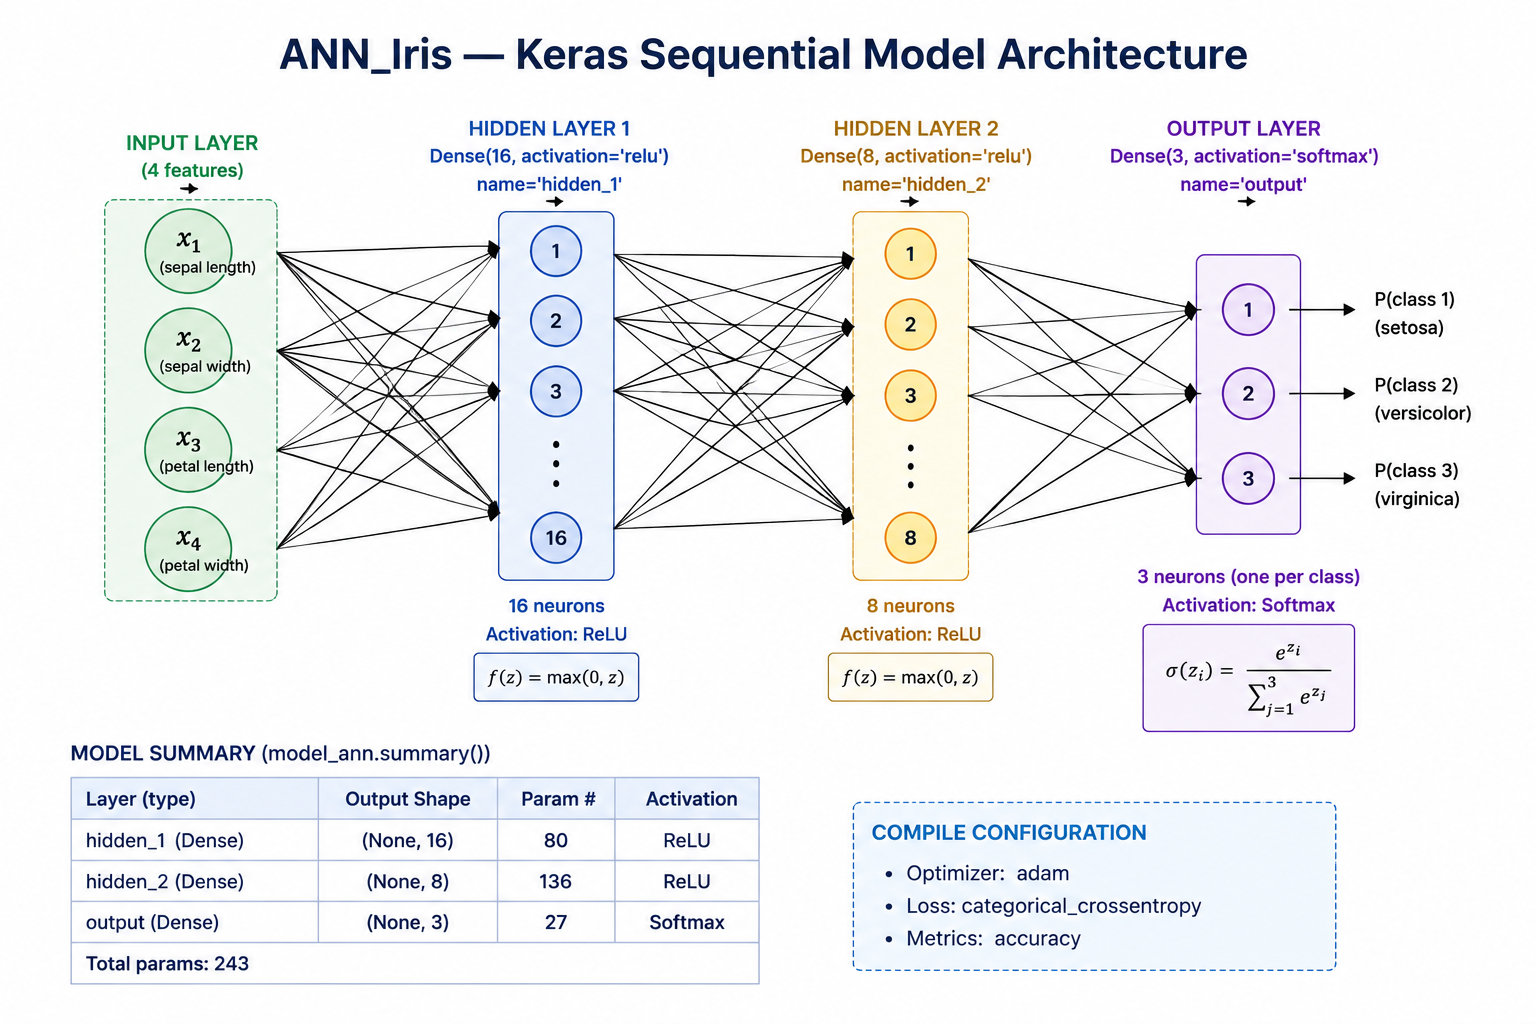

In [6]:
# ── Build the ANN with Keras Sequential API ──────────────────────────────────
tf.random.set_seed(42)

model_ann = keras.Sequential([
    # Input layer (implicit) + first hidden layer
    layers.Dense(16, activation='relu', input_shape=(4,), name='hidden_1'),
    layers.Dense(8,  activation='relu',                   name='hidden_2'),
    # Output layer: 3 neurons, one per class
    layers.Dense(3,  activation='softmax',                name='output'),
], name='ANN_Iris')

model_ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ann.summary()

Model: "ANN_Iris"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

Test accuracy : 96.67%


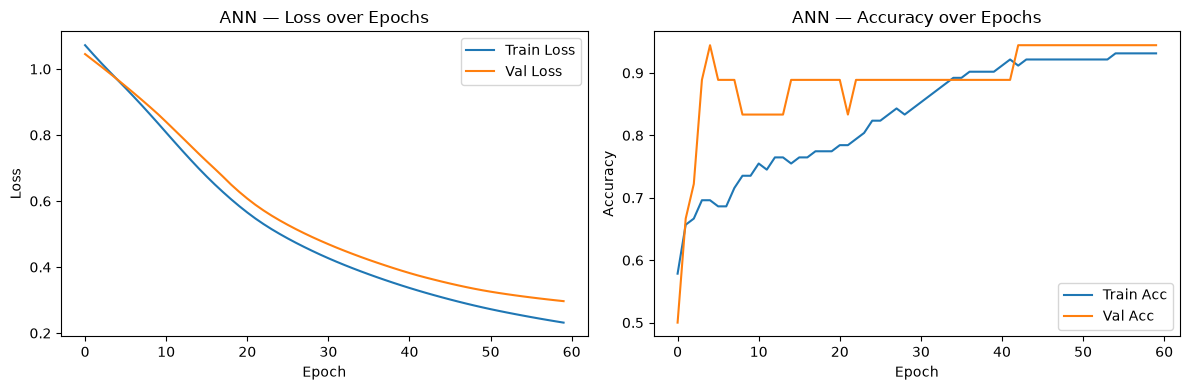

In [7]:
# ── Train the ANN ────────────────────────────────────────────────────────────
history_ann = model_ann.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.15,
    verbose=0   # silent — we will plot below
)

# Evaluate on test set
loss, acc = model_ann.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy : {acc:.2%}')

# ── Plot training curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_ann.history['loss'],     label='Train Loss')
axes[0].plot(history_ann.history['val_loss'], label='Val Loss')
axes[0].set_title('ANN — Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_ann.history['accuracy'],     label='Train Acc')
axes[1].plot(history_ann.history['val_accuracy'], label='Val Acc')
axes[1].set_title('ANN — Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# ── Make predictions on a few test samples ───────────────────────────────────
sample_indices = [0, 5, 10, 15, 25]
X_sample = X_test[sample_indices]
y_sample = y_test[sample_indices]

probs   = model_ann.predict(X_sample, verbose=0)
preds   = np.argmax(probs, axis=1)
actuals = np.argmax(y_sample, axis=1)

print('Sample Predictions\n' + '-'*50)
for i, (pred, actual, prob) in enumerate(zip(preds, actuals, probs)):
    status = '✅' if pred == actual else '❌'
    print(f'{status}  Predicted: {class_names[pred]:12s}  '
          f'Actual: {class_names[actual]:12s}  '
          f'Confidence: {prob[pred]:.0%}')

print(f'\n📌 Key point: The ANN learned to separate 3 flower species '
      f'from just 4 numeric measurements.')

Sample Predictions
--------------------------------------------------
✅  Predicted: versicolor    Actual: versicolor    Confidence: 74%
✅  Predicted: setosa        Actual: setosa        Confidence: 98%
✅  Predicted: virginica     Actual: virginica     Confidence: 84%
❌  Predicted: virginica     Actual: versicolor    Confidence: 57%
✅  Predicted: virginica     Actual: virginica     Confidence: 91%

📌 Key point: The ANN learned to separate 3 flower species from just 4 numeric measurements.


---
## 2 · CNN — Image Classification with MobileNetV2

**Architecture:** Convolutional Neural Network  
**Model:** MobileNetV2 pretrained on ImageNet (1,000 classes)  
**Task:** Classify any image — we will test with a few public domain photos

> 💡 CNNs use **convolutional filters** to detect edges → shapes → objects. MobileNetV2 was trained on 1.4 million images and can recognise 1,000 different object categories.

In [9]:
# ── Load MobileNetV2 pretrained on ImageNet ──────────────────────────────────
import ssl
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = ssl._create_unverified_context

from tensorflow.keras.applications import MobileNetV2
import ssl
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input, decode_predictions
)
ssl._create_default_https_context = ssl._create_unverified_context
from tensorflow.keras.preprocessing import image as keras_image
import requests
from PIL import Image
from io import BytesIO

# Download weights the first time (~14 MB)
cnn_model = MobileNetV2(weights='imagenet', include_top=True)
print(f'MobileNetV2 loaded — {cnn_model.count_params():,} parameters')
print('Input shape :', cnn_model.input_shape)
print('Output shape:', cnn_model.output_shape, '(1000 ImageNet classes)')

MobileNetV2 loaded — 3,538,984 parameters
Input shape : (None, 224, 224, 3)
Output shape: (None, 1000) (1000 ImageNet classes)


In [10]:
# ── Helper: load an image from URL and run inference ─────────────────────────
def classify_image(url, title=''):
    """Download an image, preprocess it, and return the top-3 predictions."""
    response = requests.get(url, timeout=10)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    img_resized = img.resize((224, 224))

    # Convert to array and preprocess (MobileNetV2 expects [-1, 1] range)
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)   # add batch dimension
    img_array = preprocess_input(img_array)

    # Predict
    preds = cnn_model.predict(img_array, verbose=0)
    top3  = decode_predictions(preds, top=3)[0]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_resized)
    axes[0].set_title(title or 'Input Image')
    axes[0].axis('off')

    labels = [f'{label} ({score:.0%})' for _, label, score in top3]
    scores = [score for _, _, score in top3]
    axes[1].barh(labels[::-1], scores[::-1], color=['#1A3A5C', '#2E75B6', '#9DC3E6'])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Top-3 Predictions')

    plt.tight_layout()
    plt.show()
    return top3

print('Helper function defined ✅')

Helper function defined ✅


In [11]:
# ── Test image 1: a cat ──────────────────────────────────────────────────────
# Public domain image from Wikimedia Commons

# TEMPORARY FIX: Redefine classify_image locally with User-Agent header
# The permanent fix should be applied to the classify_image function in the cnn-helper cell.
def classify_image(url, title=''):
    """Download an image, preprocess it, and return the top-3 predictions."""
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
    response = requests.get(url, headers=headers, timeout=10)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    img_resized = img.resize((224, 224))

    # Convert to array and preprocess (MobileNetV2 expects [-1, 1] range)
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)   # add batch dimension
    img_array = preprocess_input(img_array)

    # Predict
    preds = cnn_model.predict(img_array, verbose=0)
    top3  = decode_predictions(preds, top=3)[0]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_resized)
    axes[0].set_title(title or 'Input Image')
    axes[0].axis('off')

    labels = [f'{label} ({score:.0%})' for _, label, score in top3]
    scores = [score for _, _, score in top3]
    axes[1].barh(labels[::-1], scores[::-1], color=['#1A3A5C', '#2E75B6', '#9DC3E6'])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Top-3 Predictions')

    plt.tight_layout()
    plt.show()
    return top3

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


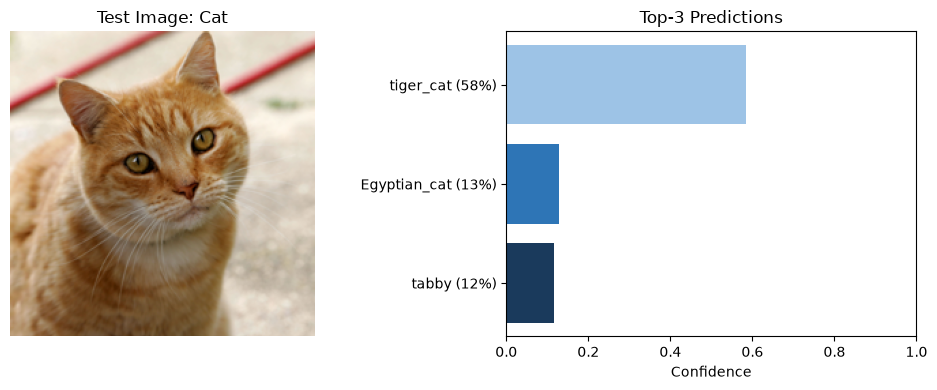


Top-3 predictions:
  1. tiger_cat                 58.44%
  2. Egyptian_cat              12.93%
  3. tabby                     11.57%


In [12]:
cat_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
top3 = classify_image(cat_url, title='Test Image: Cat')

print('\nTop-3 predictions:')
for rank, (_, label, score) in enumerate(top3, 1):
    print(f'  {rank}. {label:<25} {score:.2%}')

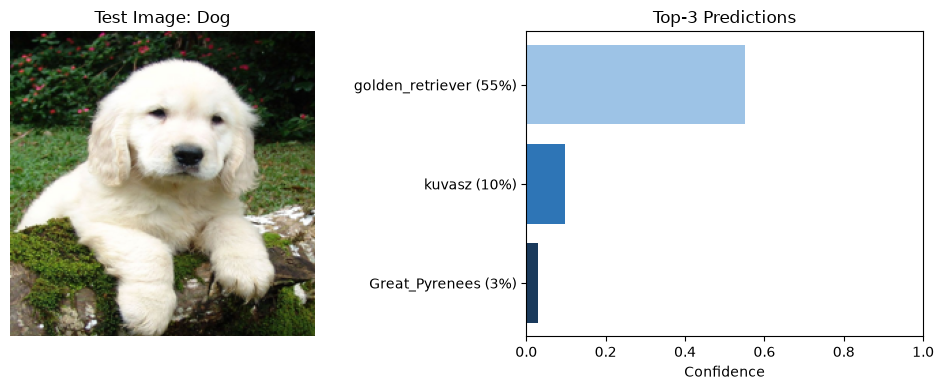


Top-3 predictions:
  1. golden_retriever          55.10%
  2. kuvasz                    9.71%
  3. Great_Pyrenees            2.93%

📌 Key point: The CNN learned visual features (edges → shapes → objects) from 1.4M training images.
   We are simply reusing those learned filters — no training needed!


In [13]:
# ── Test image 2: a dog ──────────────────────────────────────────────────────
dog_url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"
top3 = classify_image(dog_url, title='Test Image: Dog')

print('\nTop-3 predictions:')
for rank, (_, label, score) in enumerate(top3, 1):
    print(f'  {rank}. {label:<25} {score:.2%}')

print('\n📌 Key point: The CNN learned visual features (edges → shapes → objects) '
      'from 1.4M training images.\n   We are simply reusing those learned filters — '
      'no training needed!')

In [14]:
# ── 🔬 Explore: try your own image ───────────────────────────────────────────
# Replace the URL below with any public image URL you like
your_url = 'Try other URLs'

# Uncomment to classify your own image:
# classify_image(your_url, title='My Image')

print('Change the URL above and remove the # to try your own image!')

Change the URL above and remove the # to try your own image!


---
## 3 · RNN/LSTM — Sentiment Analysis with Keras

**Architecture:** Long Short-Term Memory (LSTM) — a type of RNN  
**Task:** Predict whether a movie review is positive or negative  
**Dataset:** IMDB (built-in to Keras — 25,000 labelled reviews)

> 💡 LSTMs process text **word by word**, maintaining a hidden state that carries context across the sequence. They were the dominant architecture for NLP before Transformers.

In [15]:
# ── Load the IMDB dataset (top 10,000 vocabulary) ────────────────────────────
VOCAB_SIZE   = 10_000   # keep the 10k most frequent words
MAX_LEN      = 200      # pad/truncate reviews to 200 tokens

(X_train_imdb, y_train_imdb), (X_test_imdb, y_test_imdb) = (
    keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)
)

print(f'Training reviews : {len(X_train_imdb):,}')
print(f'Test reviews     : {len(X_test_imdb):,}')
print(f'Labels           : 0 = Negative, 1 = Positive')
print(f'\nSample review (encoded): {X_train_imdb[0][:15]} ...')
print(f'Label: {"Positive" if y_train_imdb[0] == 1 else "Negative"}')

# Pad sequences to the same length
X_train_pad = keras.preprocessing.sequence.pad_sequences(
    X_train_imdb, maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_pad = keras.preprocessing.sequence.pad_sequences(
    X_test_imdb, maxlen=MAX_LEN, padding='post', truncating='post'
)
print(f'\nPadded shape: {X_train_pad.shape}')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training reviews : 25,000
Test reviews     : 25,000
Labels           : 0 = Negative, 1 = Positive

Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4] ...
Label: Positive

Padded shape: (25000, 200)


### Sample Input and Output Records for LSTM

In [16]:
print('--- Input (X_train_imdb) ---')
print(f'Shape of raw training input: {X_train_imdb.shape}')
print('First 3 raw training reviews (encoded):')
for i in range(3):
    print(f'Review {i}: {X_train_imdb[i][:20]}...') # Display first 20 tokens

print('\n--- Output (y_train_imdb) ---')
print(f'Shape of raw training labels: {y_train_imdb.shape}')
print('First 5 raw training labels:')
print(y_train_imdb[:5])

print('\n--- Padded Input (X_train_pad) ---')
print(f'Shape of padded training input: {X_train_pad.shape}')
print('First 3 padded training reviews (first 20 tokens and last 5 tokens):')
for i in range(3):
    print(f'Review {i} (start): {X_train_pad[i][:20]}...')
    print(f'Review {i} (end): {X_train_pad[i][-5:]}')

--- Input (X_train_imdb) ---
Shape of raw training input: (25000,)
First 3 raw training reviews (encoded):
Review 0: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
Review 1: [1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 4369, 5012, 134, 26, 4, 715, 8, 118, 1634, 14]...
Review 2: [1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 5974, 54, 61, 369, 13, 71, 149, 14]...

--- Output (y_train_imdb) ---
Shape of raw training labels: (25000,)
First 5 raw training labels:
[1 0 0 1 0]

--- Padded Input (X_train_pad) ---
Shape of padded training input: (25000, 200)
First 3 padded training reviews (first 20 tokens and last 5 tokens):
Review 0 (start): [   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25]...
Review 0 (end): [104   4 226  65  16]
Review 1 (start): [   1  194 1153  194 8255   78  228    5    6 1463 4369 5012  134   26
    4  715    8  118 1634   14]...
Review 1 (end): [0 0 0 0 0]
Review 2 (sta

In [17]:
# ── Helper to decode an integer-encoded review back to text ──────────────────
word_index   = keras.datasets.imdb.get_word_index()
index_to_word = {v + 3: k for k, v in word_index.items()}
index_to_word.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

def decode_review(encoded):
    return ' '.join(index_to_word.get(i, '?') for i in encoded if i > 0)

sample_text = decode_review(X_train_imdb[0][:60])
print('Decoded sample (first 60 tokens):')
print(sample_text)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Decoded sample (first 60 tokens):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film


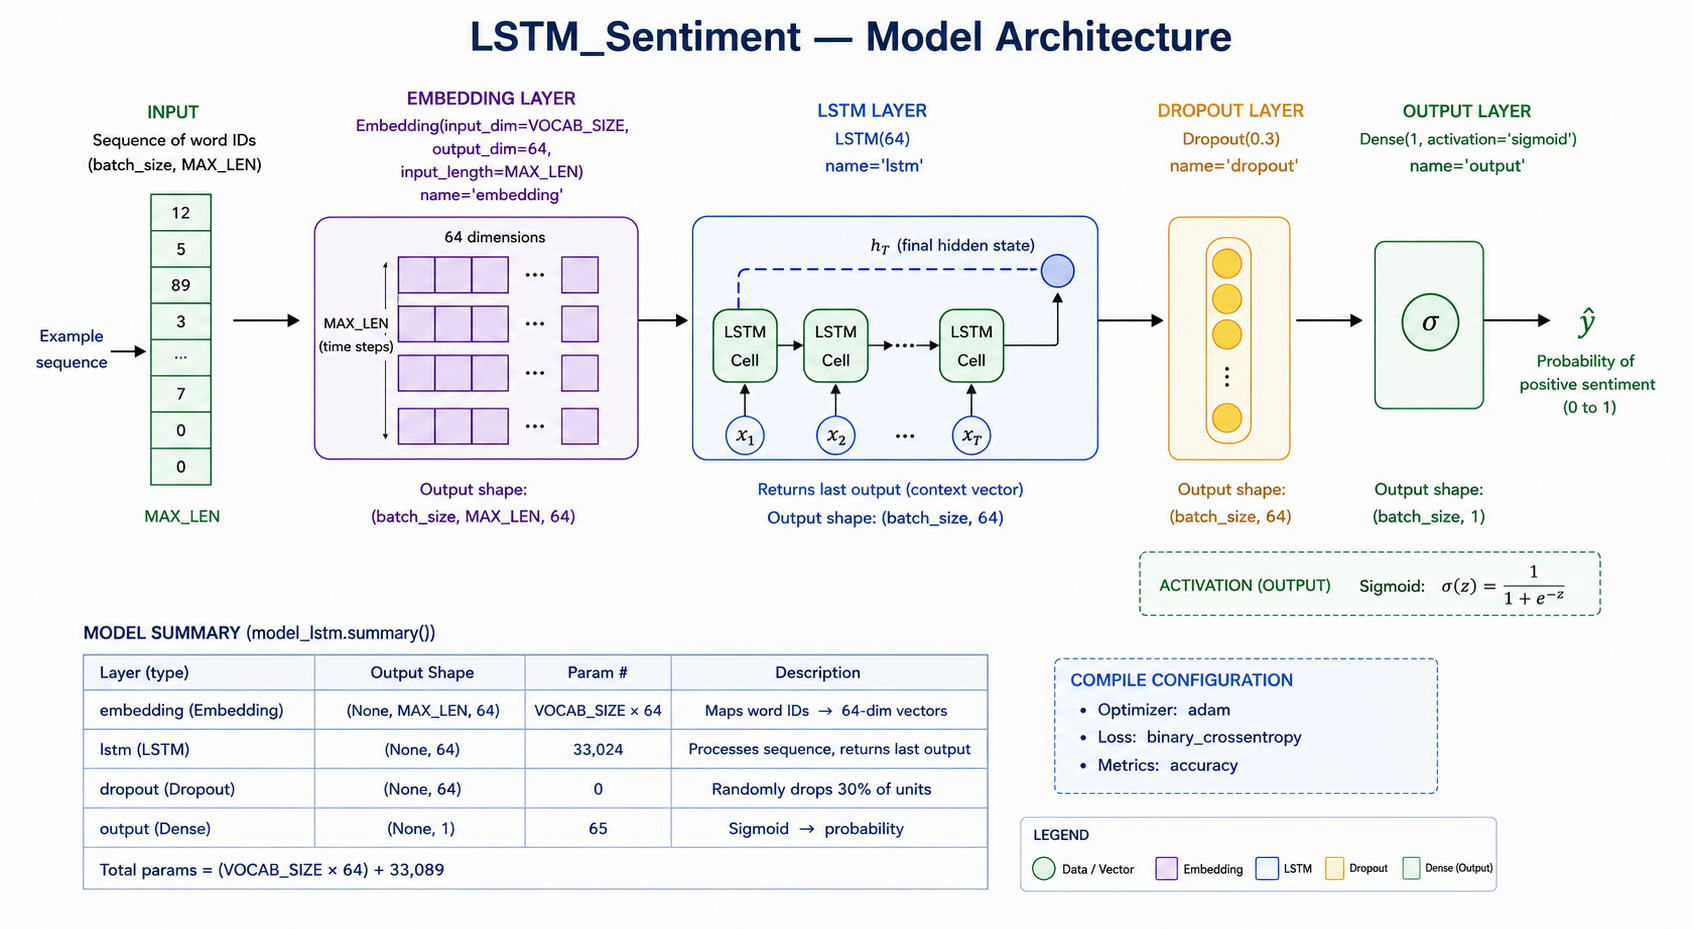

In [18]:
# ── Build the LSTM model ─────────────────────────────────────────────────────
tf.random.set_seed(42)

model_lstm = keras.Sequential([
    # Embedding: maps integer word IDs → dense 64-dim vectors
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64,
                     input_length=MAX_LEN, name='embedding'),

    # LSTM: processes the sequence and outputs a single context vector
    layers.LSTM(64, name='lstm'),

    layers.Dropout(0.3, name='dropout'),

    # Output: single neuron, sigmoid → probability of positive sentiment
    layers.Dense(1, activation='sigmoid', name='output'),
], name='LSTM_Sentiment')

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "LSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ── Train on a subset for speed (full training takes ~10 min on CPU) ──────────
# Use 5,000 samples for a quick demo; increase for better accuracy
N_TRAIN = 5_000
N_TEST  = 1_000

history_lstm = model_lstm.fit(
    X_train_pad[:N_TRAIN], y_train_imdb[:N_TRAIN],
    epochs=5,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

loss, acc = model_lstm.evaluate(
    X_test_pad[:N_TEST], y_test_imdb[:N_TEST], verbose=0
)
print(f'\nTest accuracy : {acc:.2%}  (trained on {N_TRAIN} samples only)')

Epoch 1/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.5045 - loss: 0.6930 - val_accuracy: 0.5187 - val_loss: 0.6931
Epoch 2/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.5581 - loss: 0.6870 - val_accuracy: 0.5427 - val_loss: 0.6849
Epoch 3/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.6066 - loss: 0.6502 - val_accuracy: 0.5587 - val_loss: 0.6916
Epoch 4/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6661 - loss: 0.5478 - val_accuracy: 0.5587 - val_loss: 0.7407
Epoch 5/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.7012 - loss: 0.4528 - val_accuracy: 0.5373 - val_loss: 0.8718

Test accuracy : 50.60%  (trained on 5000 samples only)


In [20]:
# ── Predict on new custom reviews ────────────────────────────────────────────
sample_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.",
    "Terrible film. Boring plot, bad acting, and a complete waste of time.",
    "It was okay. Some parts were good but overall nothing special.",
    "One of the best movies I have ever seen. Highly recommend it to everyone!",
]

def preprocess_custom_review(text):
    """Encode a raw text review as a padded integer sequence."""
    tokens = text.lower().split()
    encoded = [word_index.get(w, 2) + 3 for w in tokens]  # 2 = UNK
    encoded = [min(i, VOCAB_SIZE - 1) for i in encoded]   # clip to vocab size
    padded = keras.preprocessing.sequence.pad_sequences(
        [encoded], maxlen=MAX_LEN, padding='post', truncating='post'
    )
    return padded

print('LSTM Sentiment Predictions\n' + '-'*55)
for review in sample_reviews:
    x = preprocess_custom_review(review)
    prob = model_lstm.predict(x, verbose=0)[0][0]
    label = '😊 Positive' if prob > 0.5 else '😞 Negative'
    print(f'{label}  ({prob:.0%} positive)  |  "{review[:55]}..."')

print(f'\n📌 Key point: The LSTM read the review token-by-token, '
      f'carrying a memory of earlier words to make its prediction.')

LSTM Sentiment Predictions
-------------------------------------------------------
😊 Positive  (59% positive)  |  "This movie was absolutely fantastic! The acting was sup..."
😊 Positive  (59% positive)  |  "Terrible film. Boring plot, bad acting, and a complete ..."
😊 Positive  (59% positive)  |  "It was okay. Some parts were good but overall nothing s..."
😊 Positive  (59% positive)  |  "One of the best movies I have ever seen. Highly recomme..."

📌 Key point: The LSTM read the review token-by-token, carrying a memory of earlier words to make its prediction.


---

---
## ✏️ Exercises

Try these on your own to deepen your understanding.

**Exercise 1 — ANN**  
Change the ANN architecture: add a third hidden layer with 32 neurons. Does accuracy improve?

**Exercise 2 — CNN**  
Find a URL of any image (food, animal, vehicle) and run it through MobileNetV2. How confident is the model?

**Exercise 3 — LSTM**  
Write your own movie review (2–3 sentences). Preprocess it and run it through the LSTM. Was the prediction correct?

---

## 📋 Summary

| Architecture | What you ran | Key insight |
|---|---|---|
| **ANN** | Iris classification | Learns numeric patterns layer by layer |
| **CNN** | Image classification (MobileNetV2) | Reusable visual features — no retraining needed |
| **LSTM** | Sentiment analysis (IMDB) | Processes text token-by-token, memory fades over distance |


---
*Deep Learning Basics Session · Demo II*